## Part E: Multiple Linear Regression

* Implement Multiple Linear Regression using all relevant features.

In [10]:
import pandas as pd
df=pd.read_csv('real_estate_preprocessed.csv')
df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,0.690424,5.0,4.0,7.600000,1.0,0.381197,0.700302,1.0,0.0,1.000000,1.327625
1,100002,0.101317,3.0,3.0,6.300000,1.0,0.526719,0.268813,1.0,0.0,0.071429,0.566003
2,100003,0.810017,4.0,3.0,5.800000,1.0,0.698079,0.060065,0.0,0.0,0.100000,0.734562
3,100004,1.357822,5.0,3.0,5.610638,1.0,0.204188,0.060065,1.0,1.0,0.200000,1.453055
4,100005,-0.002070,3.0,3.0,3.800000,1.0,0.782714,-0.300670,0.0,0.0,0.062500,-0.226520


* Split data

In [11]:
X = df.drop(['house_price_inr', 'house_id'], axis=1)
y = df['house_price_inr']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

* Apply regression

In [16]:
from sklearn.linear_model import LinearRegression

lr2 = LinearRegression()
lr2.fit(X_train, y_train)

LinearRegression()

* Predict

In [17]:
y_pred = lr2.predict(X_test)
y_pred

array([-1.61642672,  0.35690094,  0.45489988, ...,  1.05801043,
       -0.75241158, -0.07641369])

* Intercept and coefficient

In [28]:
print(f'Intercept: {lr2.intercept_}')
print()
print()
print(pd.DataFrame({'feature': X.columns, 'coefficient': lr2.coef_ }))

Intercept: -1.5197807852850174


                feature   coefficient
0             area_sqft  6.183135e-01
1              bedrooms  3.841426e-02
2             bathrooms  4.149659e-02
3        location_score  2.452357e-01
4             age_years -9.020562e-17
5      distance_city_km -2.410699e-01
6         lot_size_sqft  7.777545e-02
7            has_garage  1.995160e-02
8              has_pool  4.880197e-02
9  renovation_years_ago  1.405701e-01


* Residual and homoscadasticity

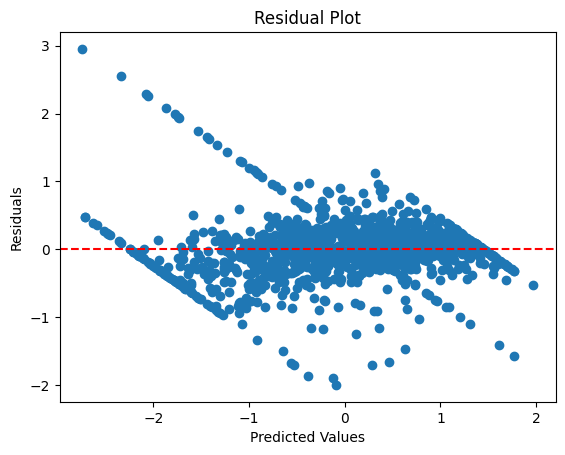

In [14]:
import matplotlib.pyplot as plt
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

* Validate multiple linear regression assumptions using plots and observations.

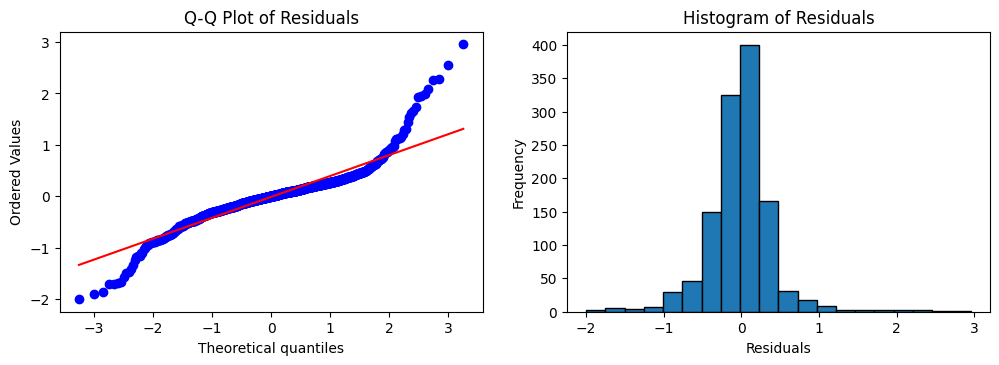

In [19]:
import scipy.stats as stats

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')

plt.subplot(2, 2, 2)
plt.hist(residuals, bins=20, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')

plt.show()

## Part D: Model Evaluation Metrics

In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
n = len(y_test)
ar2 = 1 - ((1 - r2) * (n - 1)) / (n - 1 - 1)
print(f'mse: {mse}')
print(f'mae: {mae}')
print(f'rmse: {rmse}')
print(f'r2: {r2}')
print(f'adjusted r2: {ar2}')

mse: 0.18570388044232147
mae: 0.2833383951642561
rmse: 0.43093373091732035
r2: 0.8267865352943391
adjusted r2: 0.8266427896804754


* Compare its performance with Simple Linear Regression.

Multiple regression  :
     
mse: 0.18570388044232147  
mae: 0.2833383951642561  
rmse: 0.43093373091732035  
r2: 0.8267865352943391  
adjusted r2: 0.8266427896804754  
  
Simple regression:  
  
mse: 0.4867562255583512  
mae: 0.5490733906604484  
rmse: 0.6976791709362916  
r2: 0.545982926715421  
adjusted r2: 0.5456061490612429  
  
    
  
Performance of multiple linear regression is better because the score of mse, mae, and rmse is lower and score of r2 and adjusted r2 is higher than score of simple linear regression.